# 01. Анализ признаков

**Цель**: понять, какие числовые признаки есть в данных, как они связаны с целью `ln(price)` и между собой.

**Содержание**:
1. Описание 23 числовых признаков
2. Корреляции с `ln(price)` (Pearson) + частные корреляции
3. Корреляции между предикторами (по группам)
4. PCA: биплот, scree, communality


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve()))

from helpers import (set_plot_style, load_data, impute_median, NUM_COLS_FULL,
                     FEATURE_GROUPS,
    CAT_FEATURES, FEATURE_DESCRIPTIONS)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

set_plot_style()
df, df_train, df_test = load_data()
df_train_i = impute_median(df_train, NUM_COLS_FULL)
print(f'n_train = {len(df_train_i)}, признаков числовых = {len(NUM_COLS_FULL)}')


n_train = 9480, признаков числовых = 23


## 1. Описание признаков

**23 числовых признака** + **4 категориальных**.
Числовые: отобраны по критерию fill ≥ 80%. `year` исключён — линейная функция от `age`.
Категориальные: `fuel_type`, `transmission`, `drive_type`, `body_type` — основные характеристики, ожидаемо связанные с ценой.


In [2]:
# Числовые признаки
rows = []
for c in NUM_COLS_FULL:
    unit, desc = FEATURE_DESCRIPTIONS[c]
    s = df[c].dropna()
    rows.append({
        'признак': c,
        'ед.изм.': unit,
        'описание': desc,
        'fill %': round(df[c].notna().mean() * 100, 1),
        'mean': round(s.mean(), 2),
        'std': round(s.std(), 2),
        'min': round(s.min(), 2),
        'max': round(s.max(), 2),
    })
num_desc = pd.DataFrame(rows).set_index('признак')
print('Числовые признаки:')
display(num_desc)

# Категориальные признаки
cat_rows = []
for c in CAT_FEATURES:
    vc = df[c].value_counts(dropna=False)
    cat_rows.append({
        'признак': c,
        'уровней': int(df[c].nunique()),
        'топ-3 + доли': ', '.join(f'{v}({n/len(df):.0%})' for v, n in vc.head(3).items()),
        'fill %': round(df[c].notna().mean() * 100, 1),
    })
cat_desc = pd.DataFrame(cat_rows).set_index('признак')
print('\nКатегориальные признаки:')
display(cat_desc)


Числовые признаки:


,ед.изм.,описание,fill %,mean,std,min,max
признак,,,,,,,
age,лет,Возраст автомобиля (год парсинга − год выпуска),100.0,15.15,13.03,0.0,56.0
mileage,км,Пробег,100.0,160421.30,103758.51,0.0,1000000.0
owners_count,шт,Число владельцев по ПТС,98.9,2.26,1.18,1.0,4.0
engine_power_hp,л.с.,Мощность двигателя,100.0,165.96,88.11,27.0,797.0
engine_volume,л,Рабочий объём двигателя,100.0,2.06,0.79,0.7,8.2
max_torque_nm,Н·м,Максимальный крутящий момент,96.1,260.97,147.06,52.0,1040.0
cylinders_count,шт,Число цилиндров,97.4,4.41,1.04,2.0,12.0
valves_per_cylinder,шт,Клапанов на цилиндр,97.2,3.56,0.83,2.0,5.0
gears_count,шт,Число передач КПП,88.9,5.92,1.48,1.0,10.0



Категориальные признаки:


,уровней,топ-3 + доли,fill %
признак,,,
fuel_type,4,"бензин(86%), дизель(13%), гибрид(1%)",100.0
transmission,4,"автомат(44%), механика(34%), робот(14%)",100.0
drive_type,3,"передний(51%), полный(35%), задний(13%)",100.0
body_type,15,"внедорожник(39%), седан(34%), хэтчбек(10%)",100.0


## 2. Корреляции с `ln(price)`

Pearson-корреляция показывает силу **линейной** связи. Сортируем по `|r|`.


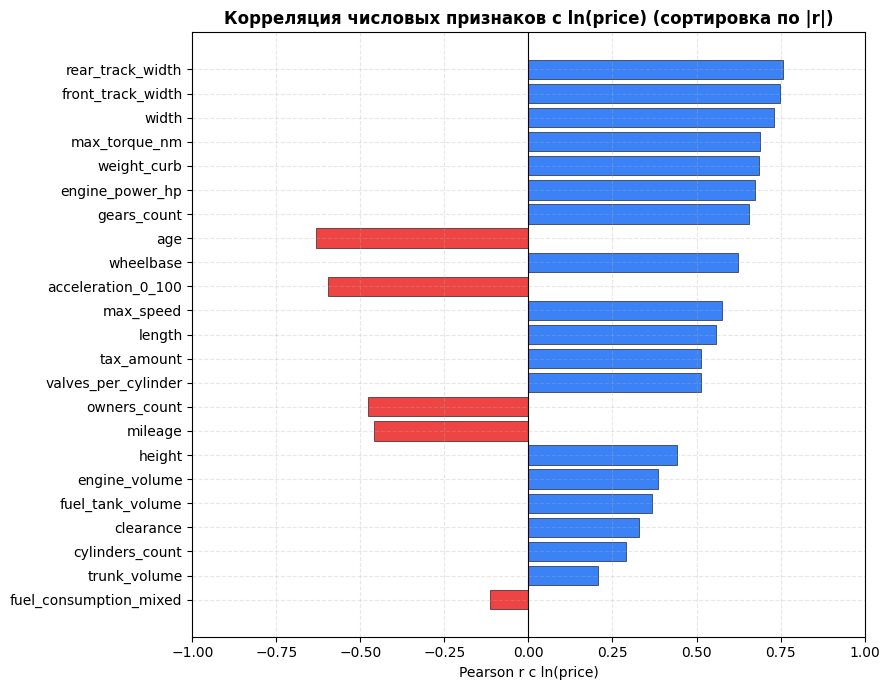

Топ-5 по |corr|:
rear_track_width     0.756
front_track_width    0.747
width                0.730
max_torque_nm        0.689
weight_curb          0.686
dtype: float64


In [3]:
corr_y = df_train_i[NUM_COLS_FULL].corrwith(df_train_i['ln_price']).sort_values(
    key=lambda s: s.abs(), ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#ef4444' if v < 0 else '#3b82f6' for v in corr_y.values]
ax.barh(corr_y.index, corr_y.values, color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlabel('Pearson r с ln(price)')
ax.set_title('Корреляция числовых признаков с ln(price) (сортировка по |r|)')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(-1, 1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('Топ-5 по |corr|:')
print(corr_y.reindex(corr_y.abs().sort_values(ascending=False).index).head(5).round(3))


### Spearman ρ — поиск монотонных нелинейностей

Pearson ловит только **линейную** связь. Spearman ρ — корреляция рангов, ловит **любую монотонную** (в т.ч. нелинейную). Разница `|ρ − r|` — индикатор нелинейности:

- `|ρ − r| ≈ 0` → связь линейна, преобразовывать признак не надо
- `|ρ − r| > 0.05` → монотонная нелинейность; кандидат на `log`, `sqrt` или степень
- `ρ велик, r мал` → сильная нелинейная связь, прямой OLS её упустит


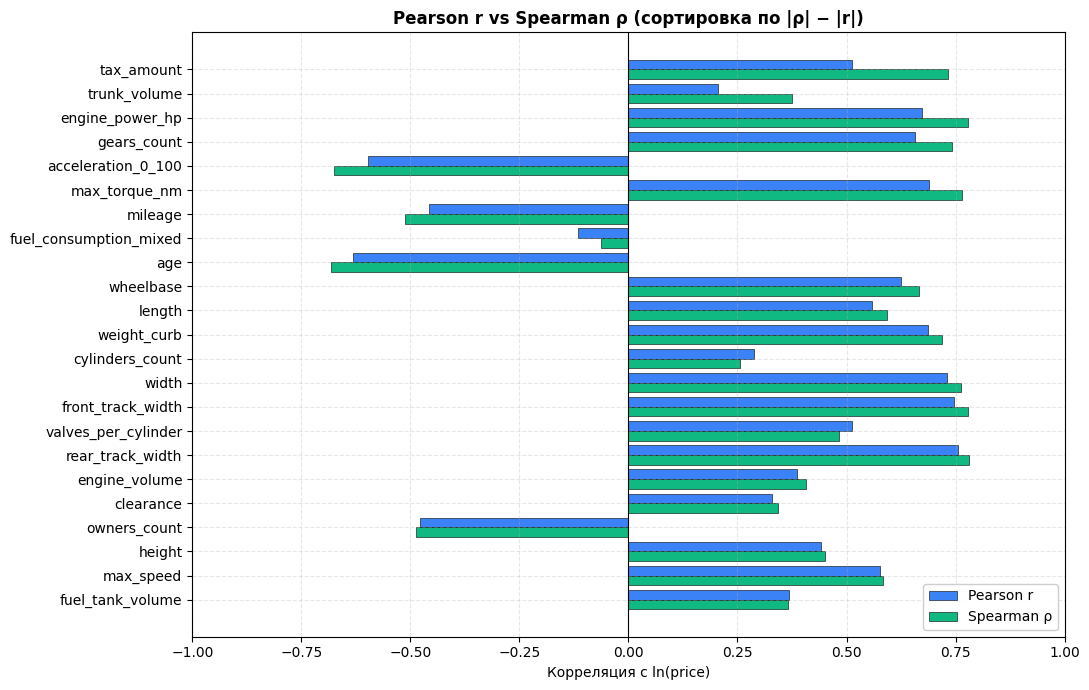

Топ-5 признаков с самой большой нелинейностью (|ρ| − |r|):
                    Pearson r  Spearman ρ  |ρ| − |r|
tax_amount              0.512       0.732      0.220
trunk_volume            0.205       0.375      0.169
engine_power_hp         0.674       0.778      0.104
gears_count             0.657       0.741      0.084
acceleration_0_100     -0.596      -0.675      0.078


In [4]:
from scipy import stats as sp_stats

spear = pd.Series({c: sp_stats.spearmanr(df_train_i[c], df_train_i['ln_price'])[0]
                   for c in NUM_COLS_FULL})
pearson = df_train_i[NUM_COLS_FULL].corrwith(df_train_i['ln_price'])
diff = (spear.abs() - pearson.abs())

comp_spear = pd.DataFrame({
    'Pearson r':  pearson.round(3),
    'Spearman ρ': spear.round(3),
    '|ρ| − |r|':  diff.round(3),
}).reindex(diff.abs().sort_values(ascending=False).index)

# Bar chart: для каждого признака — Pearson и Spearman рядом
fig, ax = plt.subplots(figsize=(11, 7))
order = comp_spear.index
yp = np.arange(len(order))
ax.barh(yp - 0.2, comp_spear['Pearson r'].values,  height=0.4,
        color='#3b82f6', edgecolor='black', linewidth=0.4, label='Pearson r')
ax.barh(yp + 0.2, comp_spear['Spearman ρ'].values, height=0.4,
        color='#10b981', edgecolor='black', linewidth=0.4, label='Spearman ρ')
ax.set_yticks(yp); ax.set_yticklabels(order)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel('Корреляция с ln(price)')
ax.set_title('Pearson r vs Spearman ρ (сортировка по |ρ| − |r|)')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print('Топ-5 признаков с самой большой нелинейностью (|ρ| − |r|):')
print(comp_spear.head(5))


### Mutual Information — ловит любую зависимость

**Mutual Information** I(X; Y) = 0 ⇔ X и Y независимы. В отличие от корреляций, MI ловит **любые** зависимости, включая немонотонные (U-образные, мульти-модальные).

- MI измеряется в `nat` (натуральные единицы информации), не нормирован к [0, 1]
- Для интерпретации полезно отношение `MI / |corr|`: если оно велико → много **нелинейного** сигнала
- Используем `sklearn.feature_selection.mutual_info_regression` (k-nearest neighbors estimator)


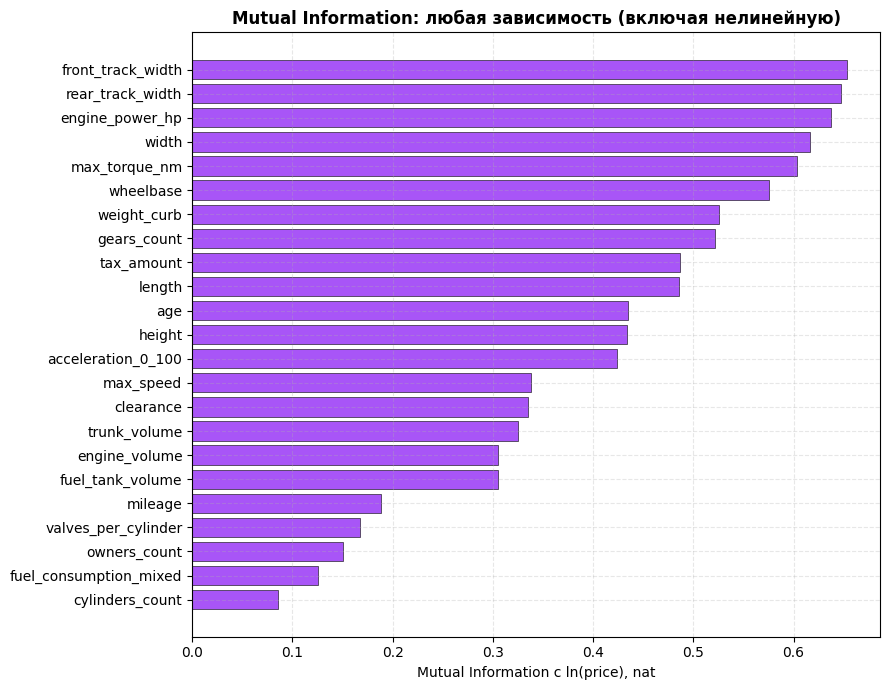

Сравнение всех трёх мер (отсортировано по MI):


,Pearson |r|,Spearman |ρ|,MI
front_track_width,0.747,0.779,0.654
rear_track_width,0.756,0.781,0.647
engine_power_hp,0.674,0.778,0.638
width,0.730,0.762,0.616
max_torque_nm,0.689,0.765,0.603
wheelbase,0.624,0.666,0.576
weight_curb,0.686,0.720,0.526
gears_count,0.657,0.741,0.522
tax_amount,0.512,0.732,0.486
length,0.558,0.593,0.485


In [5]:
from sklearn.feature_selection import mutual_info_regression

X_mi = df_train_i[NUM_COLS_FULL].values
y_mi = df_train_i['ln_price'].values
mi = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_s = pd.Series(mi, index=NUM_COLS_FULL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mi_s.index, mi_s.values, color='#a855f7', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Mutual Information с ln(price), nat')
ax.set_title('Mutual Information: любая зависимость (включая нелинейную)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Сводная таблица: Pearson, Spearman, MI
full_comp = pd.DataFrame({
    'Pearson |r|':   pearson.abs().round(3),
    'Spearman |ρ|':  spear.abs().round(3),
    'MI':            mi_s.reindex(NUM_COLS_FULL).round(3),
}).sort_values('MI', ascending=False)
print('Сравнение всех трёх мер (отсортировано по MI):')
full_comp.head(15)


**Как читать таблицу выше**:
- Если **MI высок**, а **`|r|` мал** — есть сильная **нелинейная** связь, которую OLS на сыром признаке упустит. Кандидат на feature engineering (например, добавить квадрат или взаимодействие).
- Если **MI ≈ `|r|` ≈ `|ρ|`** — связь линейна, ничего трансформировать не нужно.
- Если **`|ρ| > |r|` заметно (≥ 0.05)** — есть **монотонная нелинейность**; обычно лечится логарифмом или степенью (как `ln_mileage`, `age²`, которые мы добавляем в блоке 5).


### Частные корреляции

**Частная корреляция** `r(x_j, y | остальные)` — связь признака с `y` после удаления влияния всех остальных. Помогает выявить «уникальный» вклад каждого предиктора.


In [6]:
# Частная корреляция: на сколько y ↔ x_j остаются связаны после регрессии на остальные
from scipy import stats

partial = {}
for c in NUM_COLS_FULL:
    others = [o for o in NUM_COLS_FULL if o != c]
    X_other = sm.add_constant(df_train_i[others])
    # резидуалы y от остальных
    ey = sm.OLS(df_train_i['ln_price'], X_other).fit().resid
    # резидуалы x_c от остальных
    ex = sm.OLS(df_train_i[c], X_other).fit().resid
    partial[c] = stats.pearsonr(ex, ey)[0]

# VIF для тех же признаков
X_vif = sm.add_constant(df_train_i[NUM_COLS_FULL])
vif_map = {}
for i, col in enumerate(X_vif.columns):
    if col == 'const':
        continue
    vif_map[col] = variance_inflation_factor(X_vif.values, i)

comp = pd.DataFrame({
    'corr с ln_price': corr_y.reindex(NUM_COLS_FULL).round(3),
    'частная (контроль X)': pd.Series(partial).round(3),
    'VIF': pd.Series(vif_map).reindex(NUM_COLS_FULL).round(2),
})
comp['Δ (потеряно)'] = (comp['corr с ln_price'].abs() - comp['частная (контроль X)'].abs()).round(3)
comp = comp.sort_values('corr с ln_price', key=lambda s: s.abs(), ascending=False)
print('Чем больше Δ — тем сильнее признак «дублирует» информацию других; VIF показывает мультиколлинеарность:')
comp


Чем больше Δ — тем сильнее признак «дублирует» информацию других; VIF показывает мультиколлинеарность:


,corr с ln_price,частная (контроль X),VIF,Δ (потеряно)
rear_track_width,0.756,0.095,27.39,0.661
front_track_width,0.747,-0.026,25.48,0.721
width,0.730,0.007,10.53,0.723
max_torque_nm,0.689,0.052,8.60,0.637
weight_curb,0.686,0.103,10.00,0.583
engine_power_hp,0.674,0.057,10.33,0.617
gears_count,0.657,0.063,2.82,0.594
age,-0.631,-0.136,3.44,0.495
wheelbase,0.624,0.063,7.07,0.561
acceleration_0_100,-0.596,0.037,4.71,0.559


## 3. Категориальные предикторы

Для категориальных используем другие меры связи с `ln(price)`:
- **Boxplot** — визуально оцениваем медианы и разброс по уровням
- **ANOVA F-test** — H₀: средние `ln(price)` одинаковы во всех группах
- **η² (eta-squared)** = SS_between / SS_total — доля дисперсии Y, объяснённая категорией (аналог R² для одной переменной)
- **Tukey HSD** — попарные сравнения, помогает обнаружить группы-двойники (для бинарной сворачиваемости)


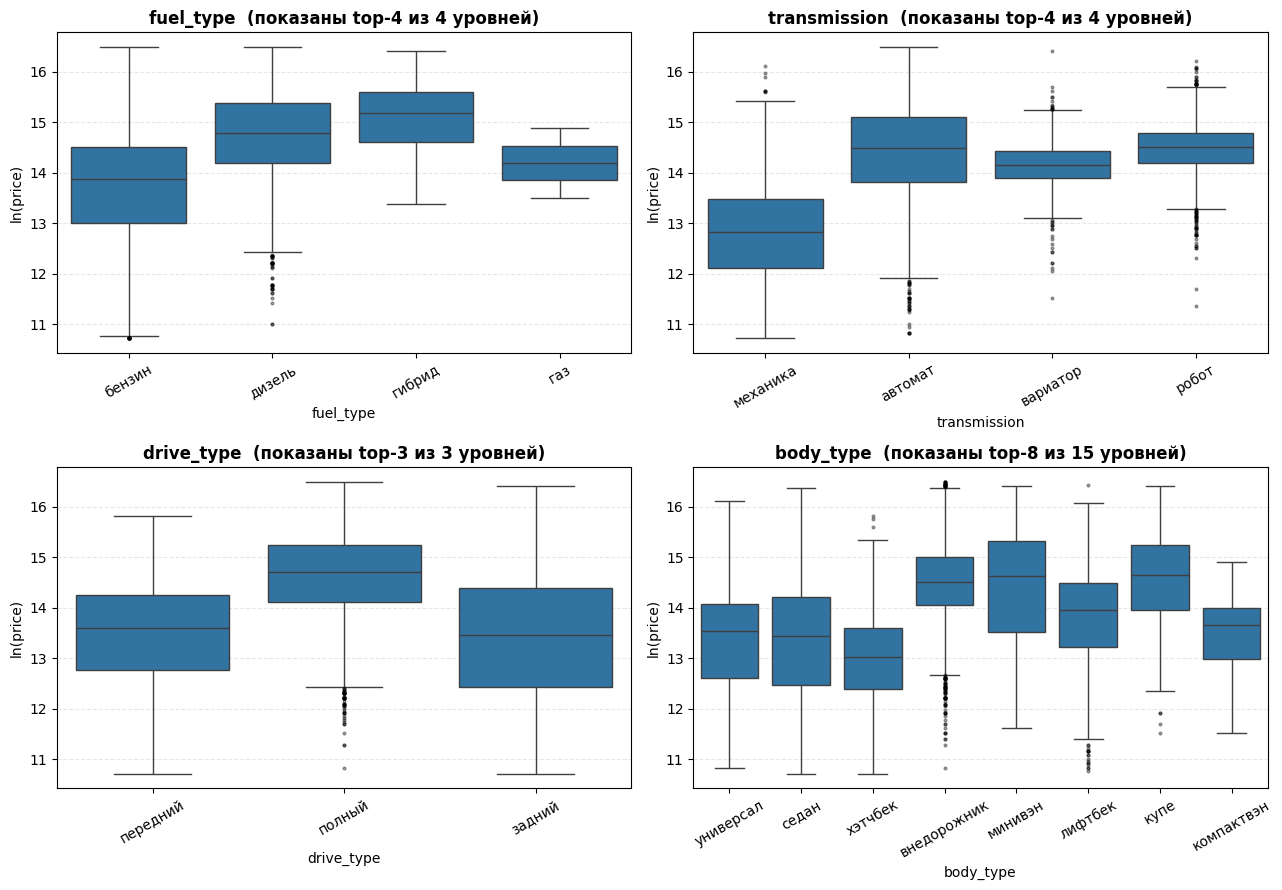

In [7]:
# Boxplot по категориям (с выбросами)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgecolor='black', alpha=0.35)
for ax, c in zip(axes.flat, CAT_FEATURES):
    top = df_train_i[c].value_counts().head(8).index
    sub = df_train_i[df_train_i[c].isin(top)]
    sns.boxplot(data=sub, x=c, y='ln_price', ax=ax, showfliers=True, flierprops=flierprops)
    ax.set_title(f'{c}  (показаны top-{len(top)} из {df_train_i[c].nunique()} уровней)')
    ax.set_xlabel(c)
    ax.set_ylabel('ln(price)')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 3.1. ANOVA F-test + η² (effect size)

**H₀**: средние `ln(price)` одинаковы во всех группах категории.
**H₁**: хотя бы одна группа отличается.

**η²** — доля дисперсии `ln(price)`, объяснённая одной категорией. Это «вклад» признака в финальный R².


In [8]:
from scipy.stats import f_oneway

anova_rows = []
for c in CAT_FEATURES:
    groups = [g['ln_price'].values for _, g in df_train_i.groupby(c) if len(g) >= 30]
    if len(groups) < 2:
        continue

    F, p = f_oneway(*groups)
    # η² = SS_between / SS_total
    means = [np.mean(g) for g in groups]
    ns = [len(g) for g in groups]
    grand_mean = np.mean(np.concatenate(groups))
    ss_between = sum(n * (m - grand_mean) ** 2 for m, n in zip(means, ns))
    ss_total = sum(((g - grand_mean) ** 2).sum() for g in groups)
    eta_sq = ss_between / ss_total

    anova_rows.append({
        'категория': c,
        'уровней (n≥30)': len(groups),
        'F': round(F, 1),
        'p-value': f'{p:.3g}',
        'η²': round(eta_sq, 4),
        'α=0.05': 'отвергаем H₀' if p < 0.05 else 'не отвергаем H₀',
    })

anova_df = pd.DataFrame(anova_rows).set_index('категория').sort_values('η²', ascending=False)
print('ANOVA: значимость каждой категории + размер эффекта (η²):')
display(anova_df)


ANOVA: значимость каждой категории + размер эффекта (η²):


,уровней (n≥30),F,p-value,η²,α=0.05
категория,,,,,
transmission,4,2422.3,0,0.4340,отвергаем H₀
body_type,11,369.1,0,0.2811,отвергаем H₀
drive_type,3,1571.6,0,0.2491,отвергаем H₀
fuel_type,3,466.5,6e-194,0.0896,отвергаем H₀


**Интерпретация η²**:
- `η² ≈ 0.13` (по Cohen): большой эффект
- `η² ≈ 0.06`: средний
- `η² < 0.01`: малый

η² — это сколько % дисперсии `ln(price)` объясняется **одной** категорией изолированно. В финальной регрессии вклад будет меньше (часть берут на себя другие признаки).


### 3.2. Tukey HSD — попарные сравнения

ANOVA говорит «хотя бы одна группа отличается», но не **какая**. Tukey HSD сравнивает все пары с поправкой на множественные сравнения.

**H₀** для каждой пары: средние ln(price) у двух уровней равны.

Зачем нужно: если `reject = False` для пары → уровни можно **схлопнуть** в один (бинарная dummy вместо k-уровневой).


In [9]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_summary_rows = []
for c in ['transmission', 'drive_type', 'fuel_type', 'body_type']:
    sub = df_train_i[[c, 'ln_price']].dropna()
    counts = sub[c].value_counts()
    keep = counts[counts >= 30].index
    sub = sub[sub[c].isin(keep)]
    if sub[c].nunique() < 2:
        continue

    t = pairwise_tukeyhsd(sub['ln_price'].values, sub[c].astype(str).values, alpha=0.05)
    tbl = pd.DataFrame(t._results_table.data[1:], columns=t._results_table.data[0])

    # аккуратное форматирование
    for col in ['meandiff', 'lower', 'upper']:
        tbl[col] = tbl[col].astype(float).round(4)
    tbl['p-adj'] = pd.to_numeric(tbl['p-adj'], errors='coerce').round(4)
    tbl['reject'] = tbl['reject'].astype(bool)
    tbl = tbl.rename(columns={
        'group1': 'группа 1',
        'group2': 'группа 2',
        'meandiff': 'Δ средних',
        'p-adj': 'p-adj',
        'lower': 'CI lower',
        'upper': 'CI upper',
        'reject': 'значимо (α=0.05)',
    }).sort_values(['значимо (α=0.05)', 'p-adj'], ascending=[True, True])

    print(f'\n=== Tukey HSD: {c} ===')
    display(
        tbl.style
        .format({'Δ средних': '{:+.4f}', 'p-adj': '{:.4f}', 'CI lower': '{:+.4f}', 'CI upper': '{:+.4f}'})
        .apply(lambda s: ['background-color: #fdecec' if v else 'background-color: #eef7ee' for v in s], subset=['значимо (α=0.05)'])
    )

    n_all = len(tbl)
    n_nonsig = int((tbl['значимо (α=0.05)'] == False).sum())
    tukey_summary_rows.append({
        'категория': c,
        'попарных сравнений': n_all,
        'незначимых пар (кандидаты на схлопывание)': n_nonsig,
    })

print('Сводка Tukey:')
display(pd.DataFrame(tukey_summary_rows).set_index('категория'))



=== Tukey HSD: transmission ===


,группа 1,группа 2,Δ средних,p-adj,CI lower,CI upper,значимо (α=0.05)
2,автомат,робот,+0.0115,0.9758,-0.0598,+0.0828,False
0,автомат,вариатор,-0.3052,0.0000,-0.3912,-0.2192,True
1,автомат,механика,-1.6457,0.0000,-1.6985,-1.5929,True
3,вариатор,механика,-1.3405,0.0000,-1.4286,-1.2524,True
4,вариатор,робот,+0.3167,0.0000,+0.2165,+0.4169,True
5,механика,робот,+1.6572,0.0000,+1.5835,+1.7310,True



=== Tukey HSD: drive_type ===


,группа 1,группа 2,Δ средних,p-adj,CI lower,CI upper,значимо (α=0.05)
0,задний,передний,+0.0083,0.9634,-0.0665,+0.0831,False
1,задний,полный,+1.2211,0.0000,+1.1428,+1.2994,True
2,передний,полный,+1.2128,0.0000,+1.1598,+1.2658,True



=== Tukey HSD: fuel_type ===


,группа 1,группа 2,Δ средних,p-adj,CI lower,CI upper,значимо (α=0.05)
0,бензин,гибрид,+1.3202,0.0000,+1.0801,+1.5603,True
1,бензин,дизель,+0.9582,0.0000,+0.8786,+1.0378,True
2,гибрид,дизель,-0.3620,0.0020,-0.6116,-0.1124,True



=== Tukey HSD: body_type ===


,группа 1,группа 2,Δ средних,p-adj,CI lower,CI upper,значимо (α=0.05)
13,кабриолет,минивэн,-0.5432,0.0836,-1.1179,+0.0314,False
0,внедорожник,кабриолет,+0.4455,0.2190,-0.0939,+0.9848,False
11,кабриолет,купе,-0.4576,0.2766,-1.0358,+0.1205,False
38,лифтбек,фургон,-0.4236,0.2966,-0.9662,+0.1190,False
20,компактвэн,лифтбек,+0.2828,0.3043,-0.0814,+0.6470,False
54,фургон,хэтчбек,-0.3654,0.4974,-0.8976,+0.1668,False
40,минивэн,пикап,+0.2585,0.5754,-0.1373,+0.6543,False
5,внедорожник,пикап,+0.1607,0.9167,-0.1818,+0.5033,False
4,внедорожник,минивэн,-0.0977,0.9243,-0.3093,+0.1138,False
14,кабриолет,пикап,-0.2847,0.9372,-0.9194,+0.3499,False


Сводка Tukey:


,попарных сравнений,незначимых пар (кандидаты на схлопывание)
категория,,
transmission,6,1
drive_type,3,1
fuel_type,3,0
body_type,55,19


**Как читать Tukey на этом шаге**:
- если для пары уровней `reject=False`, их средние `ln(price)` статистически неразличимы
- такие пары — кандидаты на **схлопывание** (бинаризация или укрупнение категорий)
- если `reject=True` почти для всех пар, категорию лучше оставить многоуровневой

Для `body_type` обычно рациональнее использовать схему **top-N + other**, а не ручное попарное схлопывание всех уровней.


## 4. Корреляции между предикторами

Признаки разбиты на 5 смысловых групп. Если внутри группы `|r| ≥ 0.85` — это группа-дубликат (мультиколлинеарность).


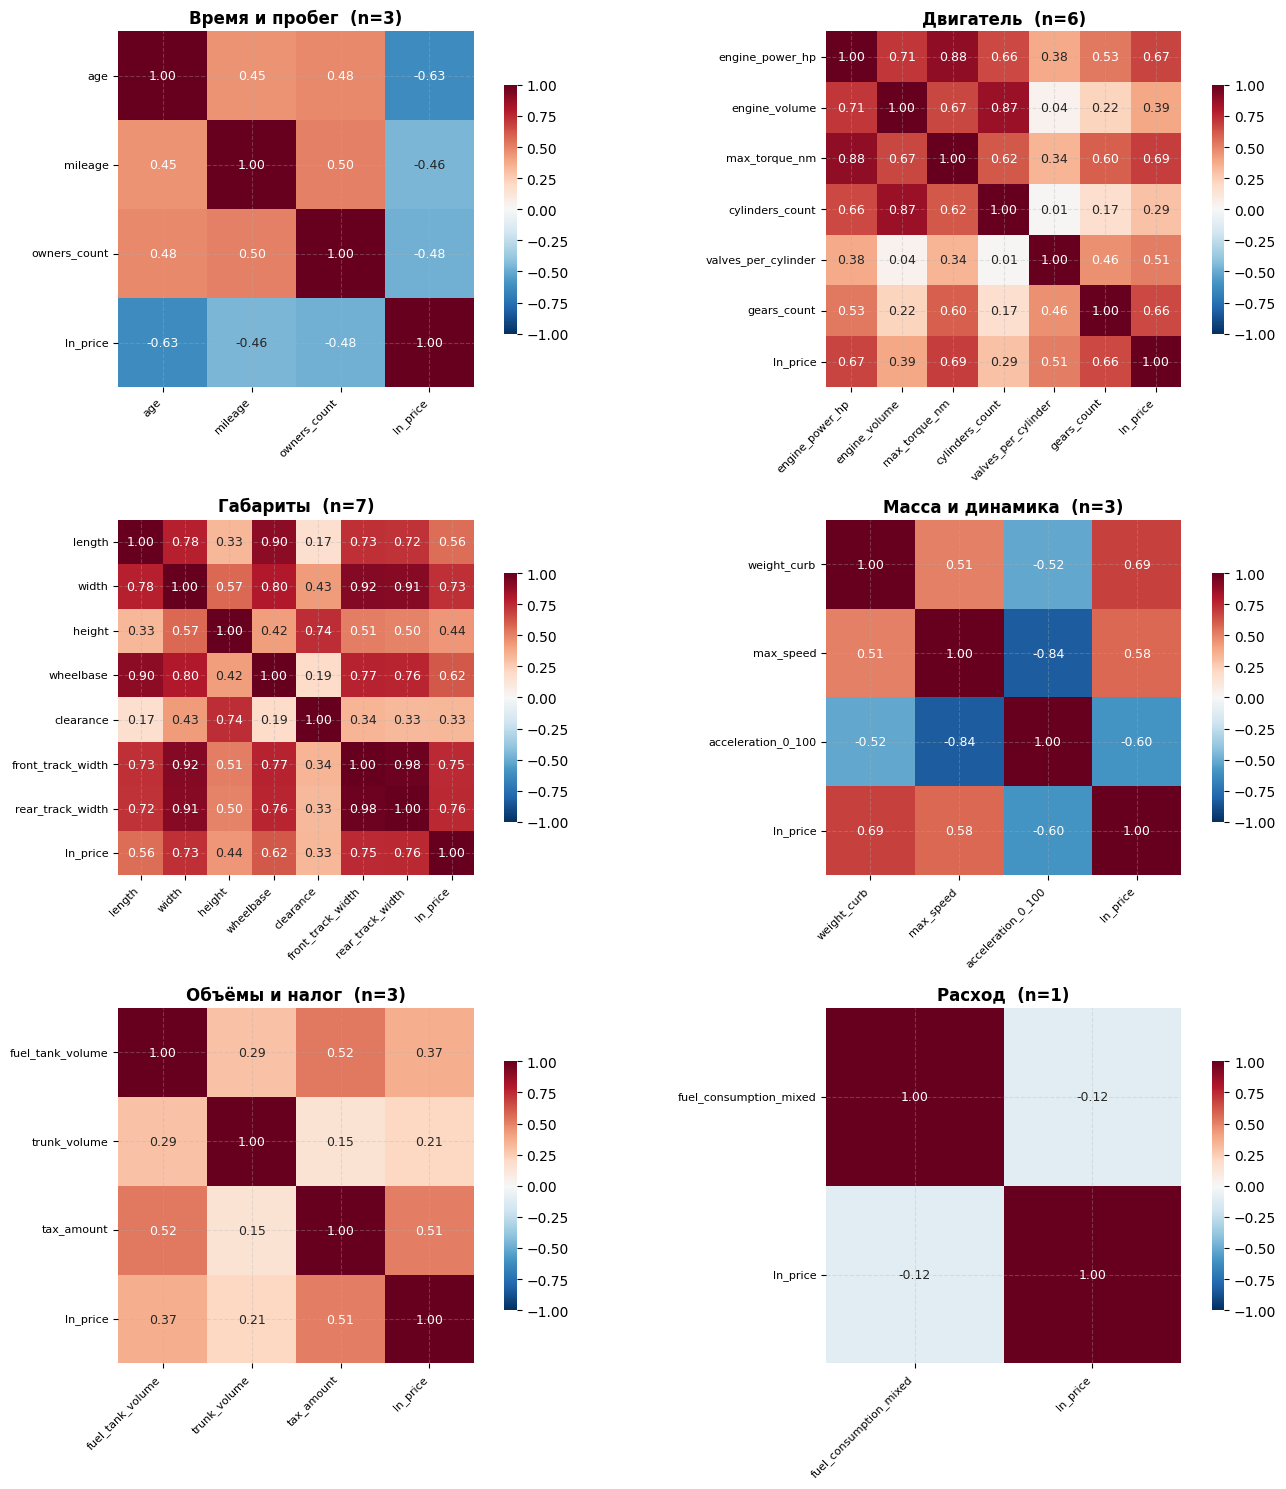

In [10]:
n_groups = len(FEATURE_GROUPS)
ncols = 2
nrows = (n_groups + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, (gname, cols) in zip(axes, FEATURE_GROUPS.items()):
    cm = df_train_i[cols + ['ln_price']].corr()
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, annot_kws={'size': 9},
                cbar_kws={'shrink': 0.7}, square=True)
    ax.set_title(f'{gname}  (n={len(cols)})')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
for ax in axes[n_groups:]:
    ax.axis('off')
plt.tight_layout(); plt.show()


### Матрица средней `|corr|` между группами

Показывает, какие группы признаков «переплетены» — это потенциальный источник мультиколлинеарности при включении в одну модель.


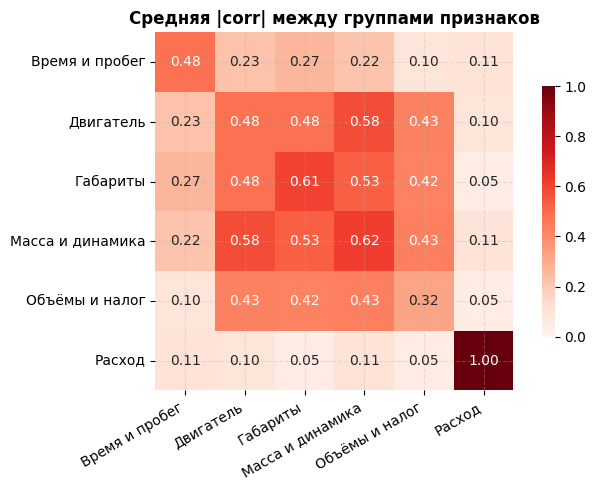

In [11]:
group_names = list(FEATURE_GROUPS.keys())
inter = pd.DataFrame(index=group_names, columns=group_names, dtype=float)
full_corr = df_train_i[NUM_COLS_FULL].corr().abs()
for g1, c1 in FEATURE_GROUPS.items():
    for g2, c2 in FEATURE_GROUPS.items():
        block = full_corr.loc[c1, c2]
        if g1 == g2 and len(c1) > 1:
            mask = ~np.eye(len(c1), dtype=bool)
            vals = block.values[mask]
        else:
            vals = block.values.flatten()
        inter.loc[g1, g2] = np.nanmean(vals) if len(vals) else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(inter.astype(float), annot=True, fmt='.2f', cmap='Reds',
            vmin=0, vmax=1, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Средняя |corr| между группами признаков')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 5. PCA — структура данных

Метод главных компонент находит ортогональные оси максимальной дисперсии. **PC1, PC2** — две главные оси, на их плоскости визуализируем все признаки (стрелки) и наблюдения (точки).


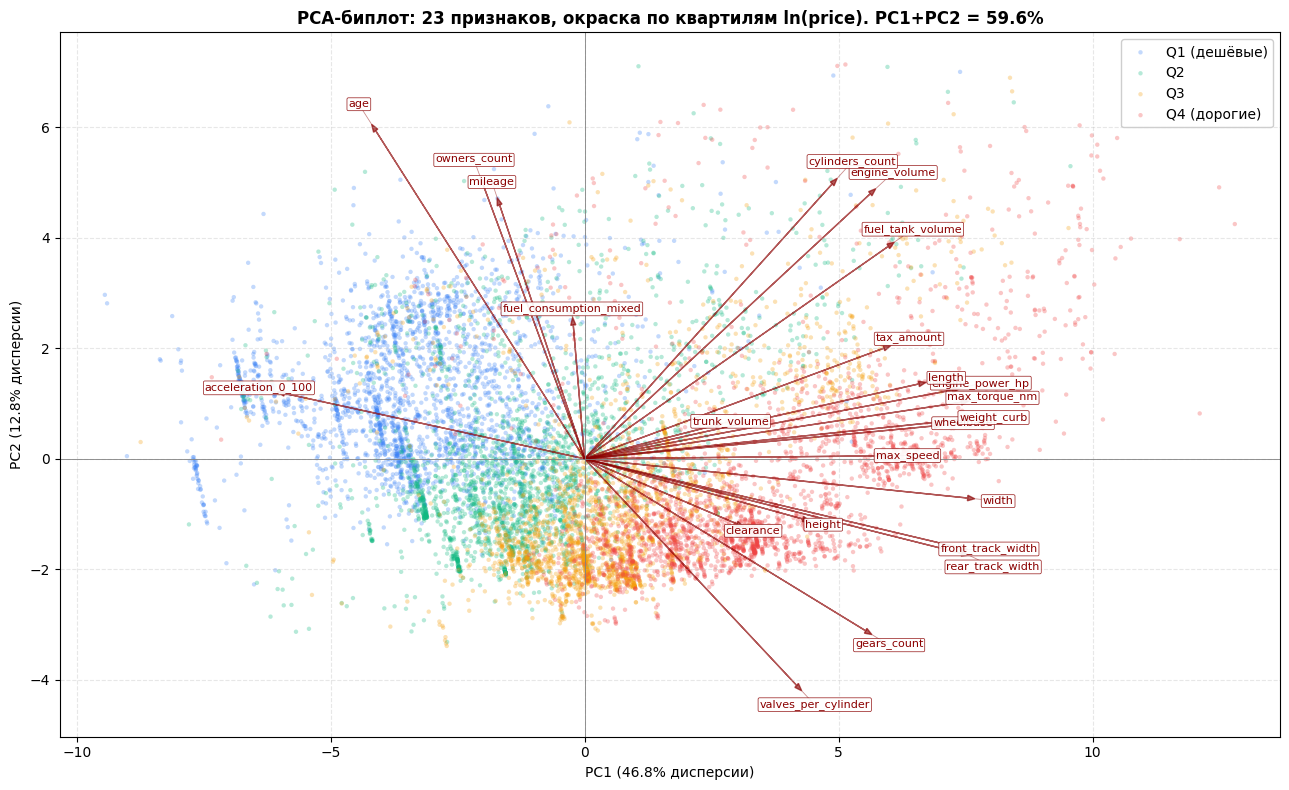

In [12]:
X_std = StandardScaler().fit_transform(df_train_i[NUM_COLS_FULL].values)
pca = PCA(n_components=2).fit(X_std)
scores = pca.transform(X_std)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
expl = pca.explained_variance_ratio_ * 100

ln_price = df_train_i['ln_price'].values
q_labels = pd.qcut(ln_price, q=4, labels=['Q1 (дешёвые)', 'Q2', 'Q3', 'Q4 (дорогие)'])
qcolors = {'Q1 (дешёвые)': '#3b82f6', 'Q2': '#10b981',
           'Q3': '#f59e0b', 'Q4 (дорогие)': '#ef4444'}

fig, ax = plt.subplots(figsize=(13, 8))
for q in qcolors:
    mask = q_labels == q
    ax.scatter(scores[mask, 0], scores[mask, 1], s=10, alpha=0.3,
               c=qcolors[q], label=q, edgecolors='none')

# Масштаб векторов под облако точек
scale = 0.60 * np.abs(scores).max() / np.abs(loadings).max()
vec = loadings * scale

# Базовая позиция подписи: рядом с кончиком вектора
tips = vec.copy()
base = tips * 1.06
labels_xy = base.copy()

# Лёгкая релаксация: разводим пересечения, но тянем подписи обратно к своим векторами
min_dist = 0.36
pull = 0.10
max_shift = 1.0
for _ in range(220):
    moved = False
    for i in range(len(labels_xy)):
        for j in range(i + 1, len(labels_xy)):
            dx = labels_xy[j, 0] - labels_xy[i, 0]
            dy = labels_xy[j, 1] - labels_xy[i, 1]
            d2 = dx * dx + dy * dy
            if d2 < min_dist * min_dist:
                d = np.sqrt(max(d2, 1e-12))
                ux, uy = dx / d, dy / d
                push = 0.5 * (min_dist - d)
                labels_xy[i, 0] -= ux * push
                labels_xy[i, 1] -= uy * push
                labels_xy[j, 0] += ux * push
                labels_xy[j, 1] += uy * push
                moved = True

    # пружинка к своей базовой точке + ограничение максимального сдвига
    delta = base - labels_xy
    labels_xy += pull * delta
    shift = labels_xy - base
    shift_norm = np.hypot(shift[:, 0], shift[:, 1])
    mask = shift_norm > max_shift
    if mask.any():
        labels_xy[mask] = base[mask] + shift[mask] / shift_norm[mask][:, None] * max_shift

    if not moved:
        break

# Отрисовка стрелок и подписей с коннекторами к своим векторам
for i, name in enumerate(NUM_COLS_FULL):
    x, y = tips[i]
    ax.arrow(0, 0, x, y, head_width=0.10, head_length=0.14,
             fc='darkred', ec='darkred', alpha=0.65, linewidth=1.0, length_includes_head=True)

    lx, ly = labels_xy[i]
    # линия-привязка, чтобы всегда видно, к какой стрелке подпись относится
    ax.plot([x, lx], [y, ly], color='darkred', alpha=0.45, lw=0.6)
    ax.text(lx, ly, name, fontsize=8, color='darkred', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.92, edgecolor='darkred',
                      boxstyle='round,pad=0.13', linewidth=0.5))

# Границы осей: учитываем и облако, и подписи
all_x = np.r_[scores[:, 0], labels_xy[:, 0], tips[:, 0]]
all_y = np.r_[scores[:, 1], labels_xy[:, 1], tips[:, 1]]
x_pad = 0.04 * (all_x.max() - all_x.min())
y_pad = 0.05 * (all_y.max() - all_y.min())
ax.set_xlim(all_x.min() - x_pad, all_x.max() + x_pad)
ax.set_ylim(all_y.min() - y_pad, all_y.max() + y_pad)

ax.axhline(0, color='gray', lw=0.6)
ax.axvline(0, color='gray', lw=0.6)
ax.set_xlabel(f'PC1 ({expl[0]:.1f}% дисперсии)')
ax.set_ylabel(f'PC2 ({expl[1]:.1f}% дисперсии)')
ax.set_title(f'PCA-биплот: {len(NUM_COLS_FULL)} признаков, окраска по квартилям ln(price). '
             f'PC1+PC2 = {expl.sum():.1f}%')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


### Scree plot — сколько PC нужно

`PCA` выполняется только для **числовых** признаков, потому что работает с ковариационной/корреляционной матрицей непрерывных переменных.

Для категориальных аналог — `MCA` (Multiple Correspondence Analysis), а для смешанных данных — `FAMD`.


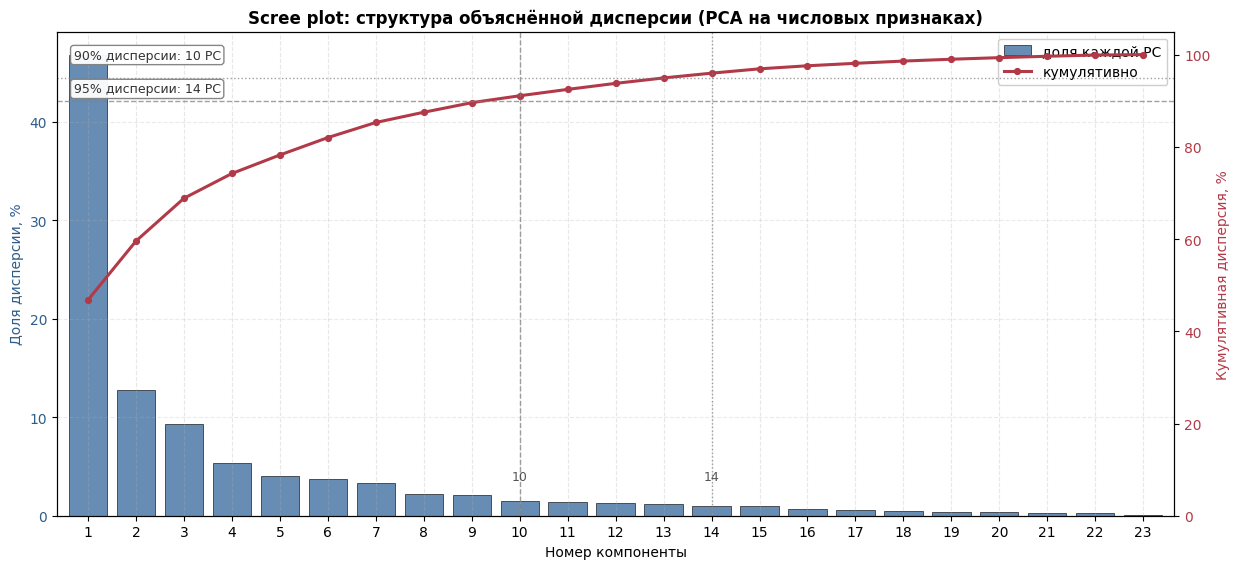

Для 90% дисперсии нужно 10 компонент из 23
Для 95% дисперсии нужно 14 компонент из 23


In [13]:
full_pca = PCA().fit(X_std)
vr = full_pca.explained_variance_ratio_
cum = np.cumsum(vr)
n_90 = int(np.argmax(cum >= 0.90) + 1)
n_95 = int(np.argmax(cum >= 0.95) + 1)
expl = vr * 100

fig, ax1 = plt.subplots(figsize=(12.5, 5.8))
x = np.arange(1, len(vr) + 1)
ax1.bar(x, expl, color='#4E79A7', alpha=0.85, edgecolor='black', linewidth=0.5, label='доля каждой PC')
ax1.set_xlabel('Номер компоненты')
ax1.set_ylabel('Доля дисперсии, %', color='#2F5D8A')
ax1.tick_params(axis='y', labelcolor='#2F5D8A')
ax1.set_xticks(x)
ax1.set_xlim(0.35, len(vr) + 0.65)
ax1.grid(axis='y', alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(x, cum * 100, color='#B23A48', marker='o', markersize=4.2, lw=2.2, label='кумулятивно')
ax2.set_ylabel('Кумулятивная дисперсия, %', color='#B23A48')
ax2.tick_params(axis='y', labelcolor='#B23A48')
ax2.set_ylim(0, 105)
ax2.grid(False)

# Пороговые линии
ax2.axhline(90, color='gray', ls='--', lw=1.0, alpha=0.75)
ax2.axhline(95, color='gray', ls=':', lw=1.0, alpha=0.75)
ax2.axvline(n_90, color='gray', ls='--', lw=1.0, alpha=0.75)
ax2.axvline(n_95, color='gray', ls=':', lw=1.0, alpha=0.75)

# Подписи без стрелок: фиксированные бейджи + подписи у вертикальных линий
ax2.text(0.015, 0.965, f'90% дисперсии: {n_90} PC', transform=ax2.transAxes,
         fontsize=9, color='#333', va='top', ha='left',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.25', alpha=0.95))
ax2.text(0.015, 0.895, f'95% дисперсии: {n_95} PC', transform=ax2.transAxes,
         fontsize=9, color='#333', va='top', ha='left',
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.25', alpha=0.95))

ax2.text(n_90, 7, f'{n_90}', color='#555', fontsize=9, ha='center', va='bottom')
if n_95 != n_90:
    ax2.text(n_95, 7, f'{n_95}', color='#555', fontsize=9, ha='center', va='bottom')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Scree plot: структура объяснённой дисперсии (PCA на числовых признаках)')
plt.tight_layout()
plt.show()

print(f'Для 90% дисперсии нужно {n_90} компонент из {len(NUM_COLS_FULL)}')
print(f'Для 95% дисперсии нужно {n_95} компонент из {len(NUM_COLS_FULL)}')


### Communality и интерпретация PC1, PC2

**Communality** = сумма квадратов loadings признака по первым 10 PC = доля дисперсии **данного признака**, которая объясняется этими PC.


In [14]:
L_full = full_pca.components_.T * np.sqrt(full_pca.explained_variance_)
L_df = pd.DataFrame(L_full, index=NUM_COLS_FULL,
                    columns=[f'PC{i+1}' for i in range(L_full.shape[1])])
comm10 = (L_df.iloc[:, :n_90]**2).sum(axis=1)

summary_pc = pd.DataFrame({
    'corr с ln_price': corr_y.reindex(NUM_COLS_FULL).round(3),
    '|PC1| (loading)': L_df['PC1'].abs().round(3),
    '|PC2| (loading)': L_df['PC2'].abs().round(3),
    f'communality_{n_90}PC': comm10.round(3),
}).sort_values('|PC1| (loading)', ascending=False)

print('Полная таблица loadings/communality (без обрезки):')
display(summary_pc)


Полная таблица loadings/communality (без обрезки):


,corr с ln_price,|PC1| (loading),|PC2| (loading),communality_10PC
width,0.730,0.919,0.087,0.912
weight_curb,0.686,0.909,0.087,0.907
rear_track_width,0.756,0.905,0.209,0.915
max_torque_nm,0.689,0.904,0.125,0.878
front_track_width,0.747,0.902,0.197,0.906
engine_power_hp,0.674,0.883,0.152,0.925
wheelbase,0.624,0.841,0.073,0.901
length,0.558,0.804,0.165,0.903
fuel_tank_volume,0.367,0.730,0.469,0.841
acceleration_0_100,-0.596,0.724,0.145,0.882


In [15]:
print('PC1 ({:.1f}%) топ-5:'.format(expl[0]))
for f, v in L_df['PC1'].abs().sort_values(ascending=False).head(5).items():
    print(f'  {f:22s} {L_df.loc[f,"PC1"]:+.3f}')
print(f'  → ось «размер + мощность»')
print()
print('PC2 ({:.1f}%) топ-5:'.format(expl[1]))
for f, v in L_df['PC2'].abs().sort_values(ascending=False).head(5).items():
    print(f'  {f:22s} {L_df.loc[f,"PC2"]:+.3f}')
print(f'  → ось «возраст + износ»')


PC1 (46.8%) топ-5:
  width                  +0.919
  weight_curb            +0.909
  rear_track_width       +0.905
  max_torque_nm          +0.904
  front_track_width      +0.902
  → ось «размер + мощность»

PC2 (12.8%) топ-5:
  age                    +0.724
  owners_count           +0.611
  cylinders_count        +0.607
  engine_volume          +0.585
  mileage                +0.565
  → ось «возраст + износ»


## Выводы блока 1

1. **23 числовых признака** с fill ≥ 80%; ~10 из них имеют `|corr|` с `ln(price)` ≥ 0.5.
2. **Сильная мультиколлинеарность** внутри групп «Габариты» и «Двигатель» (`|r| ≥ 0.85` для нескольких пар). Простое включение всех 23 в OLS даст высокий VIF.
3. **PCA**: PC1 (~44%) = «размер + мощность», PC2 (~13%) = «возраст + износ». Эти оси ортогональны → возраст и размер машины — независимые сигналы цены.
4. **Эффективная размерность** — 10 PC из 23 покрывают 90% дисперсии. Остальные 13 — избыточность/шум.

→ В блоке 2 формализуем процедуру отбора признаков на основе этих наблюдений.
